In [5]:
!pip install -q kaggle -q
!pip install -q timm -q

In [6]:
import os
import gc
import time
import zipfile
import random
from google.colab import drive, files
import numpy as np
import pandas as pd
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import LabelEncoder
import cv2
import albumentations as A
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import timm

In [7]:
BASE = '/content/drive/MyDrive/MINE/Machine Learning Techniques/PROYECTO/CircleID'
DATA = f'{BASE}/data'
IMG_DIR = f'{DATA}/images'

folders = [
    f'{BASE}/data',
    f'{BASE}/features',
    f'{BASE}/checkpoints',
    f'{BASE}/models',
    f'{BASE}/submissions',
    f'{BASE}/logs',
    f'{BASE}/export'
]

In [8]:
for f in folders:
    os.makedirs(f, exist_ok=True)

In [9]:
uploaded = files.upload()

os.makedirs('/root/.kaggle', exist_ok=True)
os.rename('kaggle.json', '/root/.kaggle/kaggle.json')
os.chmod('/root/.kaggle/kaggle.json', 0o600)

Saving kaggle.json to kaggle.json


In [10]:
# data de competencia
!kaggle competitions download -c icdar-2026-circleid-writer-identification -p /content/temp_zip

zip_dir = '/content/temp_zip'
zip_files = [f for f in os.listdir(zip_dir) if f.endswith('.zip')]
print(f"Found zip files: {zip_files}")

for zf in zip_files:
    zip_path = os.path.join(zip_dir, zf)
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(DATA)
    os.remove(zip_path)

os.rmdir(zip_dir)
gc.collect()

for root, dirs, files_list in os.walk(DATA):
    depth = root.replace(DATA, '').count(os.sep)
    if depth < 2:
        indent = '  ' * depth
        print(f"{indent}{os.path.basename(root)}/")
        if depth == 1:
            print(f"{indent}  ({len(files_list)} archivos)")

100% 414M/414M [00:24<00:00, 17.4MB/s]

Found zip files: ['icdar-2026-circleid-writer-identification.zip']
data/
  images/
    (46155 archivos)


# Entendimiento

In [11]:
# dataframes
train_df = pd.read_csv(f'{DATA}/train.csv')
add_df = pd.read_csv(f'{DATA}/additional_train.csv')
test_df = pd.read_csv(f'{DATA}/test.csv')
sub_df = pd.read_csv(f'{DATA}/sample_submission.csv')

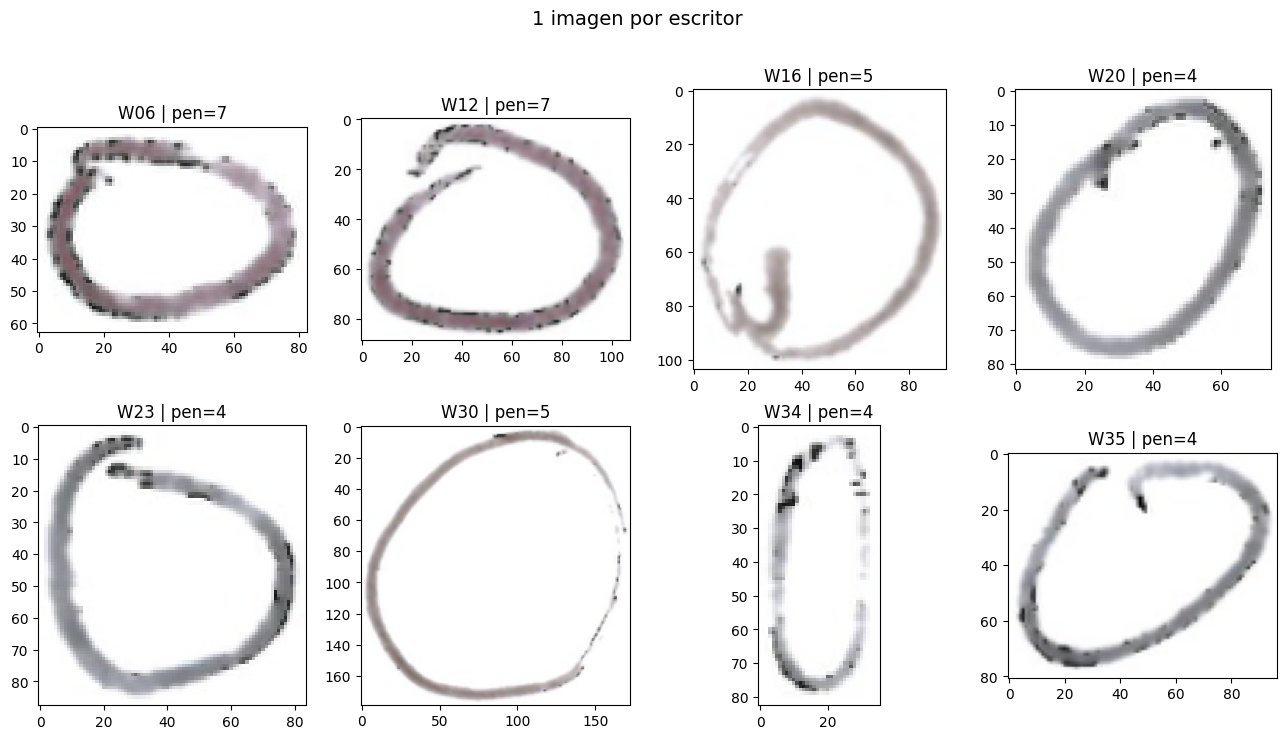

In [12]:
# mostrar escritores
w = random.sample(list(train_df['writer_id'].unique()), 8)

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for i, writer in enumerate(sorted(w)):
    writer_imgs = train_df[train_df['writer_id'] == writer]
    row = writer_imgs.sample(1).iloc[0]

    img_path = os.path.join(DATA, row['image_path'])
    img = cv2.imread(img_path)
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    axes[i].imshow(img)
    axes[i].set_title(f"{writer} | pen={row['pen_id']}", fontsize=12)

plt.suptitle('1 imagen por escritor', fontsize=14)
plt.show()

In [13]:
sizes = []
for idx, row in train_df.head(20).iterrows():
    img_path = os.path.join(DATA, row['image_path'])
    img = cv2.imread(img_path)
    sizes.append(img.shape)

for s in sizes[:5]:
    print(f"  {s}")

  (109, 82, 3)
  (109, 82, 3)
  (110, 64, 3)
  (69, 89, 3)
  (102, 99, 3)


# Entrenamientos

## Preparación

In [14]:
# preparar para encontrar unknowns
add_known = add_df[add_df['writer_id'] != '-1'].copy()
add_unknown = add_df[add_df['writer_id'] == '-1'].copy()

all_writers = sorted(train_df['writer_id'].unique())

random.seed(42)
np.random.seed(42)

s_writers = all_writers.copy()
random.shuffle(s_writers)

n_unknown_per_fold = 8
n_folds = 3

cv_splits = []

for fold in range(n_folds):
    start = fold * n_unknown_per_fold
    end = start + n_unknown_per_fold

    if end <= len(s_writers):
        fake_unknown_writers = s_writers[start:end]
    else:
        fake_unknown_writers = s_writers[start:] + s_writers[:end - len(s_writers)]

    known_writers_fold = [w for w in all_writers if w not in fake_unknown_writers]

    known_train_df = train_df[train_df['writer_id'].isin(known_writers_fold)]

    known_val_dfs = []
    known_trn_dfs = []
    for w in known_writers_fold:
        w_data = known_train_df[known_train_df['writer_id'] == w]
        w_data = w_data.sample(frac=1, random_state=42)
        split_idx = int(len(w_data) * 0.8)
        known_trn_dfs.append(w_data.iloc[:split_idx])
        known_val_dfs.append(w_data.iloc[split_idx:])

    fold_train = pd.concat(known_trn_dfs)
    fold_known_val = pd.concat(known_val_dfs)

    fold_unknown_val = train_df[train_df['writer_id'].isin(fake_unknown_writers)]
    real_unknowns = add_unknown.sample(n=min(500, len(add_unknown)), random_state=fold)

    split_info = {
        'fold': fold,
        'known_writers': known_writers_fold,
        'fake_unknown_writers': fake_unknown_writers,
        'train_df': fold_train,
        'known_val_df': fold_known_val,
        'unknown_val_df': pd.concat([fold_unknown_val, real_unknowns]),
    }
    cv_splits.append(split_info)

In [15]:
def load_and_preprocess(img_path, target_size=224):
    """
    preparar imagenes, cuadradas, greyscale
    """
    img = cv2.imread(img_path)
    if img is None:
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    h, w = gray.shape
    max_side = max(h, w)

    canvas = np.ones((max_side, max_side), dtype=np.uint8) * 255
    y_off = (max_side - h) // 2
    x_off = (max_side - w) // 2
    canvas[y_off:y_off+h, x_off:x_off+w] = gray

    resized = cv2.resize(canvas, (target_size, target_size), interpolation=cv2.INTER_AREA)

    return resized

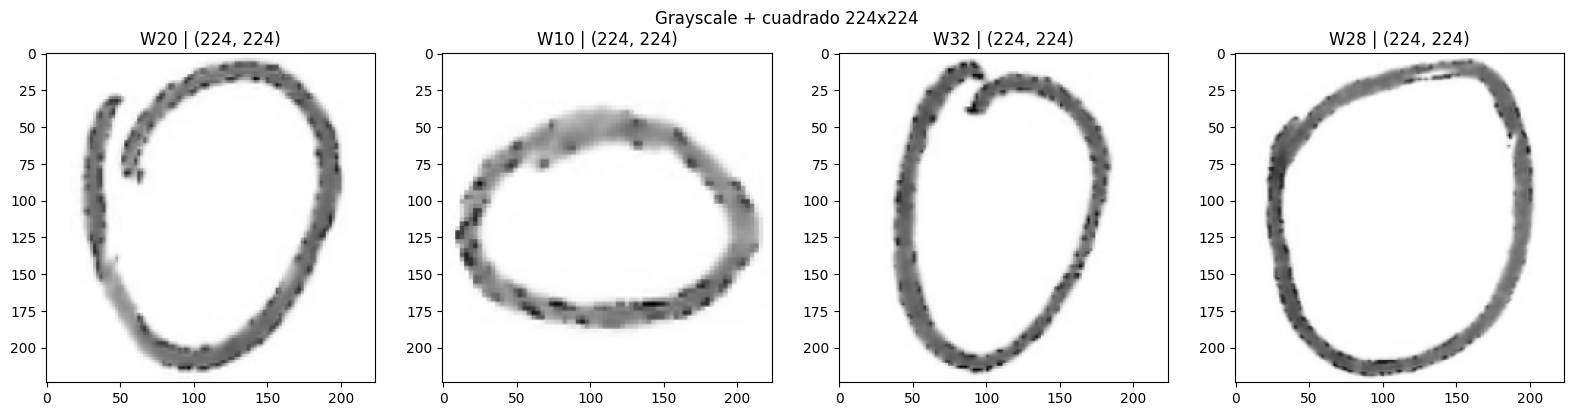

In [16]:
# visualizar
test_rows = train_df.sample(4, random_state=7)

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

for i, (_, row) in enumerate(test_rows.iterrows()):
    img_path = os.path.join(DATA, row['image_path'])
    processed = load_and_preprocess(img_path)

    axes[i].imshow(processed, cmap='gray')
    axes[i].set_title(f"{row['writer_id']} | {processed.shape}")

plt.suptitle('Grayscale + cuadrado 224x224')
plt.tight_layout()
plt.show()

## Aumentación

In [17]:
def load_and_preprocess(img_path, target_size=224):
    img = cv2.imread(img_path)
    if img is None:
        print(f"ERROR: {img_path}")
        return None

    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    h, w = gray.shape
    max_side = max(h, w)
    canvas = np.ones((max_side, max_side), dtype=np.uint8) * 255
    y_off = (max_side - h) // 2
    x_off = (max_side - w) // 2
    canvas[y_off:y_off + h, x_off:x_off + w] = gray
    resized = cv2.resize(canvas, (target_size, target_size), interpolation=cv2.INTER_AREA)
    img_3ch = np.stack([resized, resized, resized], axis=-1)

    return img_3ch

In [18]:
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

# normalizar despues
train_transform = A.Compose([
    A.ShiftScaleRotate(
        shift_limit=0.1,
        scale_limit=0.15,
        rotate_limit=15,
        border_mode=cv2.BORDER_CONSTANT,
        value=255,
        p=0.7
    ),
    A.ElasticTransform(
        alpha=30,
        sigma=4,
        border_mode=cv2.BORDER_CONSTANT,
        value=255,
        p=0.3
    ),
    A.GaussNoise(var_limit=(5, 25), p=0.3),
    A.CoarseDropout(
        max_holes=4,
        max_height=16,
        max_width=16,
        fill_value=255,
        p=0.2
    ),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = A.Compose([
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


/usr/local/lib/python3.12/dist-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_19744/89705169.py:6: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(
/tmp/ipykernel_19744/89705169.py:14: UserWarning: Argument(s) 'value' are not valid for transform ElasticTransform
  A.ElasticTransform(
/tmp/ipykernel_19744/89705169.py:21: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5, 25), p=0.3),
/tmp/ipykernel_19744/89705169.py:22: UserWarning: Argument(s) 'max_holes, max_height, max_width, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(


/tmp/ipykernel_19744/1480513669.py:22: UserWarning: Argument(s) 'value' are not valid for transform ShiftScaleRotate
  A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=15,
/tmp/ipykernel_19744/1480513669.py:24: UserWarning: Argument(s) 'value' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=30, sigma=4, border_mode=cv2.BORDER_CONSTANT,
/tmp/ipykernel_19744/1480513669.py:26: UserWarning: Argument(s) 'var_limit' are not valid for transform GaussNoise
  A.GaussNoise(var_limit=(5, 25), p=0.3),
/tmp/ipykernel_19744/1480513669.py:27: UserWarning: Argument(s) 'max_holes, max_height, max_width, fill_value' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=4, max_height=16, max_width=16,


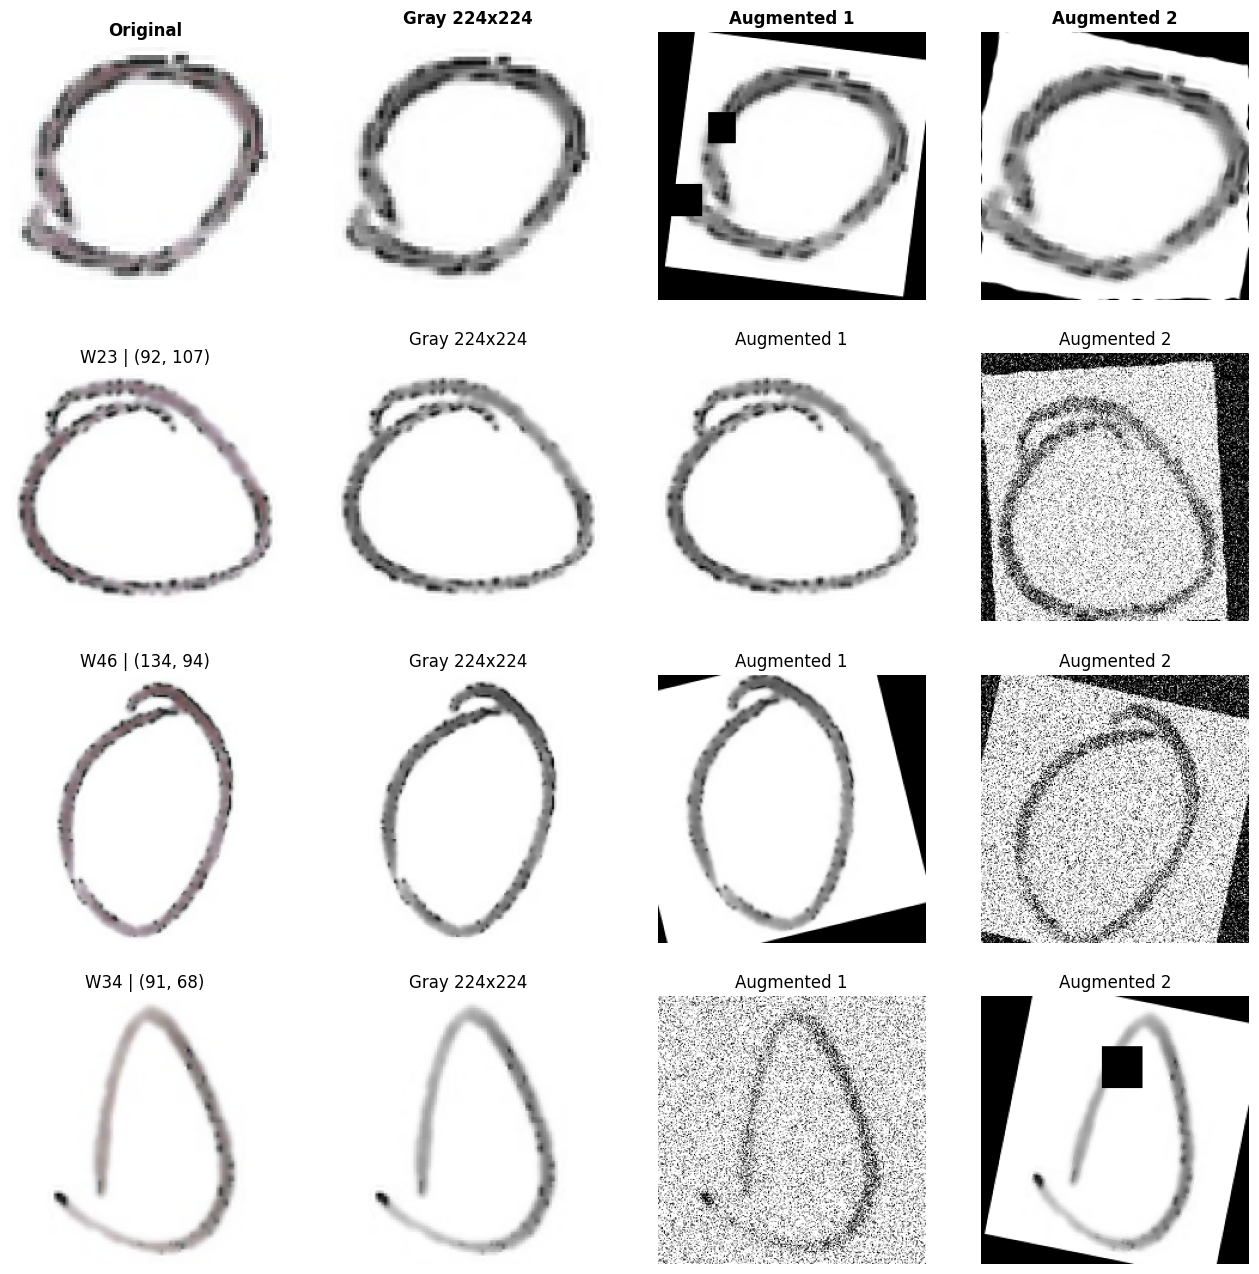

In [19]:
s = train_df.sample(4, random_state=42)

fig, axes = plt.subplots(4, 4, figsize=(16, 16))
col_titles = ['Original', 'Gray 224x224', 'Augmented 1', 'Augmented 2']

for i, (_, row) in enumerate(s.iterrows()):
    img_path = os.path.join(DATA, row['image_path'])

    # original
    orig = cv2.imread(img_path)
    orig = cv2.cvtColor(orig, cv2.COLOR_BGR2RGB)
    axes[i, 0].imshow(orig)
    axes[i, 0].set_title(f"{row['writer_id']} | {orig.shape[:2]}")

    # grayscale 3ch
    processed = load_and_preprocess(img_path, target_size=224)
    axes[i, 1].imshow(processed[:, :, 0], cmap='gray')
    axes[i, 1].set_title('Gray 224x224')

    # augmented
    aug_visual = A.Compose([
        A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.15, rotate_limit=15,
                           border_mode=cv2.BORDER_CONSTANT, value=255, p=0.7),
        A.ElasticTransform(alpha=30, sigma=4, border_mode=cv2.BORDER_CONSTANT,
                           value=255, p=0.3),
        A.GaussNoise(var_limit=(5, 25), p=0.3),
        A.CoarseDropout(max_holes=4, max_height=16, max_width=16,
                        fill_value=255, p=0.2),
    ])

    for j in range(2):
        aug_result = aug_visual(image=processed)
        aug_img = aug_result['image']
        axes[i, 2 + j].imshow(aug_img[:, :, 0], cmap='gray')
        axes[i, 2 + j].set_title(f'Augmented {j + 1}')

for ax_row in axes:
    for ax in ax_row:
        ax.axis('off')

for j, title in enumerate(col_titles):
    axes[0, j].set_title(title, fontsize=12, fontweight='bold')

plt.show()

## PyTorch Datasets y Loaders

In [20]:
# Splits

random.seed(42)
np.random.seed(42)

add_unknown = add_df[add_df['writer_id'] == '-1'].copy()
add_known = add_df[add_df['writer_id'] != '-1'].copy()
all_writers = sorted(train_df['writer_id'].unique())
shuffled_writers = all_writers.copy()
random.shuffle(shuffled_writers)

n_unknown_per_fold = 8
n_folds = 3
cv_splits = []

for fold in range(n_folds):
    start = fold * n_unknown_per_fold
    end = start + n_unknown_per_fold
    if end <= len(shuffled_writers):
        fake_unknown_writers = shuffled_writers[start:end]
    else:
        fake_unknown_writers = shuffled_writers[start:] + shuffled_writers[:end - len(shuffled_writers)]

    known_writers_fold = [w for w in all_writers if w not in fake_unknown_writers]

    known_trn_dfs = []
    known_val_dfs = []
    for w in known_writers_fold:
        w_data = train_df[train_df['writer_id'] == w].sample(frac=1, random_state=42)
        split_idx = int(len(w_data) * 0.8)
        known_trn_dfs.append(w_data.iloc[:split_idx])
        known_val_dfs.append(w_data.iloc[split_idx:])

    fold_train = pd.concat(known_trn_dfs)
    fold_known_val = pd.concat(known_val_dfs)
    fold_unknown_val = train_df[train_df['writer_id'].isin(fake_unknown_writers)]
    real_unknowns = add_unknown.sample(n=min(500, len(add_unknown)), random_state=fold)

    cv_splits.append({
        'fold': fold,
        'known_writers': known_writers_fold,
        'fake_unknown_writers': fake_unknown_writers,
        'train_df': fold_train,
        'known_val_df': fold_known_val,
        'unknown_val_df': pd.concat([fold_unknown_val, real_unknowns]),
    })

In [21]:
# Clase datasets
class CircleDataset(Dataset):
    """
    carga imagenes para clasificacion de escritor
    """
    def __init__(self, dataframe, data_dir, label_encoder, known_writers_list,
                 transform=None, is_test=False):
        self.df = dataframe.reset_index(drop=True)
        self.data_dir = data_dir
        self.le = label_encoder
        self.known_writers = set(known_writers_list)
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img_path = os.path.join(self.data_dir, row['image_path'])

        # cargar
        img = cv2.imread(img_path)
        if img is None:
            img = np.ones((224, 224, 3), dtype=np.uint8) * 255
        else:
            gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            h, w = gray.shape
            max_side = max(h, w)
            canvas = np.ones((max_side, max_side), dtype=np.uint8) * 255
            y_off = (max_side - h) // 2
            x_off = (max_side - w) // 2
            canvas[y_off:y_off + h, x_off:x_off + w] = gray
            resized = cv2.resize(canvas, (224, 224), interpolation=cv2.INTER_AREA)
            img = np.stack([resized, resized, resized], axis=-1)

        if self.transform:
            augmented = self.transform(image=img)
            img = augmented['image']

        img = torch.from_numpy(img.transpose(2, 0, 1)).float()

        if self.is_test:
            image_id = row['image_id']
            return img, image_id
        else:
            writer_id = str(row['writer_id'])
            if writer_id in self.known_writers:
                label = self.le.transform([writer_id])[0]
            else:
                label = -1
            return img, label


In [22]:
# transform

IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = A.Compose([
    A.Affine(
        translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)},
        scale=(0.85, 1.15),
        rotate=(-15, 15),
        mode=cv2.BORDER_CONSTANT,
        cval=255,
        p=0.7
    ),
    A.ElasticTransform(
        alpha=30,
        sigma=4,
        border_mode=cv2.BORDER_CONSTANT,
        p=0.3
    ),
    A.GaussNoise(std_range=(0.02, 0.05), p=0.3),
    A.CoarseDropout(
        num_holes_range=(1, 4),
        hole_height_range=(8, 16),
        hole_width_range=(8, 16),
        fill=255,
        p=0.2
    ),
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

val_transform = A.Compose([
    A.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


/tmp/ipykernel_19744/4264047667.py:7: UserWarning: Argument(s) 'mode, cval' are not valid for transform Affine
  A.Affine(


In [23]:
# Data por fold

split = cv_splits[0]

fold_le = LabelEncoder()
fold_le.fit(split['known_writers'])
FOLD_NUM_CLASSES = len(fold_le.classes_)

add_known_fold = add_known[add_known['writer_id'].isin(split['known_writers'])]
augmented_train_df = pd.concat([split['train_df'], add_known_fold])

# datasets
train_dataset = CircleDataset(
    augmented_train_df, DATA, fold_le, split['known_writers'],
    transform=train_transform
)
known_val_dataset = CircleDataset(
    split['known_val_df'], DATA, fold_le, split['known_writers'],
    transform=val_transform
)
unknown_val_dataset = CircleDataset(
    split['unknown_val_df'], DATA, fold_le, split['known_writers'],
    transform=val_transform
)

# dataloaders
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True,
                          num_workers=2, pin_memory=True)
known_val_loader = DataLoader(known_val_dataset, batch_size=64, shuffle=False,
                              num_workers=2, pin_memory=True)
unknown_val_loader = DataLoader(unknown_val_dataset, batch_size=64, shuffle=False,
                                num_workers=2, pin_memory=True)

In [24]:
# Verificaciones finales

# training
imgs, labels = next(iter(train_loader))
print(f"\nTraining batch:")
print(f"  Images: {imgs.shape}, dtype={imgs.dtype}")
print(f"  Labels: min={labels.min().item()}, max={labels.max().item()}")
print(f"  S: {labels[:10].tolist()}")

# known val
imgs_k, labels_k = next(iter(known_val_loader))
print(f"\nKnown val batch:")
print(f"  Labels: min={labels_k.min().item()}, max={labels_k.max().item()}")
print(f"  S: {labels_k[:10].tolist()}")

# unknown val
imgs_u, labels_u = next(iter(unknown_val_loader))
print(f"\nUnknown val batch:")
print(f"  Labels: min={labels_u.min().item()}, max={labels_u.max().item()}")
print(f"  S: {labels_u[:10].tolist()}")
has_neg = any(labels_u == -1)




Training batch:
  Images: torch.Size([64, 3, 224, 224]), dtype=torch.float32
  Labels: min=0, max=35
  S: [19, 25, 12, 17, 24, 8, 0, 25, 3, 11]

Known val batch:
  Labels: min=0, max=0
  S: [0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

Unknown val batch:
  Labels: min=-1, max=-1
  S: [-1, -1, -1, -1, -1, -1, -1, -1, -1, -1]


In [25]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"\nDevice: {device}")
if device.type == 'cuda':
    print(f"  GPU: {torch.cuda.get_device_name(0)}")
    print(f"  VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")


Device: cuda
  GPU: Tesla T4
  VRAM: 15.6 GB


## EfficientNet-B0

In [26]:
device = torch.device('cuda')
torch.backends.cudnn.benchmark = True

train_df = pd.read_csv(f'{DATA}/train.csv')
add_df = pd.read_csv(f'{DATA}/additional_train.csv')
add_unknown = add_df[add_df['writer_id'] == '-1'].copy()
add_known = add_df[add_df['writer_id'] != '-1'].copy()

# fold 0
all_writers = sorted(train_df['writer_id'].unique())
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

shuffled = all_writers.copy()
random.shuffle(shuffled)

fake_unknowns = shuffled[0:8]
known_writers = [w for w in all_writers if w not in fake_unknowns]

trn_parts, val_parts = [], []
for w in known_writers:
    wd = train_df[train_df['writer_id'] == w].sample(frac=1, random_state=42)
    cut = int(len(wd) * 0.8)
    trn_parts.append(wd.iloc[:cut])
    val_parts.append(wd.iloc[cut:])

fold_train = pd.concat(trn_parts + [add_known[add_known['writer_id'].isin(known_writers)]])
fold_known_val = pd.concat(val_parts)
fold_unknown_val = pd.concat([
    train_df[train_df['writer_id'].isin(fake_unknowns)],
    add_unknown.sample(n=500, random_state=0)
])

le = LabelEncoder() # enconder para writers
le.fit(known_writers)
NUM_CLASSES = len(le.classes_)
known_set = set(known_writers)

print(f"{NUM_CLASSES} | {len(fold_train)} | {len(fold_known_val)} | {len(fold_unknown_val)}")

36 | 24360 | 3890 | 4900


In [27]:
# transformar
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

aug_train = A.Compose([
    A.Affine(translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)},
             scale=(0.85, 1.15), rotate=(-15, 15),
             border_mode=cv2.BORDER_CONSTANT, fill=255, p=0.7),
    A.ElasticTransform(alpha=30, sigma=4, border_mode=cv2.BORDER_CONSTANT, p=0.3),
    A.GaussNoise(std_range=(0.02, 0.05), p=0.3),
    A.CoarseDropout(num_holes_range=(1, 4), hole_height_range=(8, 16),
                    hole_width_range=(8, 16), fill=255, p=0.2),
    A.Normalize(mean=MEAN, std=STD),
])

aug_val = A.Compose([A.Normalize(mean=MEAN, std=STD)])

# dataset
class CircleDS(Dataset):
    def __init__(self, df, transform, is_test=False):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(os.path.join(DATA, row['image_path']))
        if img is None:
            img = np.ones((224, 224, 3), dtype=np.uint8) * 255
        else:
            g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            h, w = g.shape
            s = max(h, w)
            c = np.ones((s, s), dtype=np.uint8) * 255
            c[(s-h)//2:(s-h)//2+h, (s-w)//2:(s-w)//2+w] = g
            r = cv2.resize(c, (224, 224), interpolation=cv2.INTER_AREA)
            img = np.stack([r, r, r], axis=-1)

        img = self.transform(image=img)['image']
        img = torch.from_numpy(img.transpose(2, 0, 1)).float()

        if self.is_test:
            return img, row['image_id']

        wid = str(row['writer_id'])
        label = le.transform([wid])[0] if wid in known_set else -1
        return img, label

train_loader = DataLoader(CircleDS(fold_train, aug_train), batch_size=64,
                          shuffle=True, num_workers=2, pin_memory=True)
known_val_loader = DataLoader(CircleDS(fold_known_val, aug_val), batch_size=64,
                              shuffle=False, num_workers=2, pin_memory=True)
unknown_val_loader = DataLoader(CircleDS(fold_unknown_val, aug_val), batch_size=64,
                                shuffle=False, num_workers=2, pin_memory=True)


In [28]:
# modelo
model = timm.create_model('efficientnet_b0', pretrained=True, num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
scaler = torch.amp.GradScaler('cuda')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/21.4M [00:00<?, ?B/s]

In [29]:
# entrenar cabeza
for name, p in model.named_parameters():
    if 'classifier' not in name:
        p.requires_grad = False

optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                               lr=1e-4, weight_decay=1e-4)


for epoch in range(5):
    model.train()
    losses, correct, total = [], 0, 0
    t0 = time.time()

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            out = model(imgs)
            loss = criterion(out, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        losses.append(loss.item())
        correct += (out.argmax(1) == labels).sum().item()
        total += len(labels)

    print(f"  Epoch {epoch+1}/5 | Loss: {np.mean(losses):.4f} | "
          f"Acc: {correct/total:.4f} | {time.time()-t0:.0f}s")

# entrenar el resto
for p in model.parameters():
    p.requires_grad = True

optimizer = torch.optim.AdamW([
    {'params': [p for n, p in model.named_parameters() if 'classifier' not in n], 'lr': 1e-5},
    {'params': model.classifier.parameters(), 'lr': 1e-4},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

best_acc = 0.0
for epoch in range(15):
    model.train()
    losses, correct, total = [], 0, 0
    t0 = time.time()

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            out = model(imgs)
            loss = criterion(out, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        losses.append(loss.item())
        correct += (out.argmax(1) == labels).sum().item()
        total += len(labels)

    scheduler.step()

    model.eval()
    ok, tot = 0, 0
    with torch.no_grad():
        for imgs, labels in known_val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            with torch.amp.autocast('cuda'):
                out = model(imgs)
            probs = torch.softmax(out, dim=1)
            mx, pred = probs.max(1)
            for j in range(len(labels)):
                tot += 1
                if mx[j].item() >= 0.5 and pred[j].item() == labels[j].item():
                    ok += 1

        for imgs, labels in unknown_val_loader:
            imgs = imgs.to(device)
            with torch.amp.autocast('cuda'):
                out = model(imgs)
            probs = torch.softmax(out, dim=1)
            mx = probs.max(1)[0]
            for j in range(len(labels)):
                tot += 1
                if mx[j].item() < 0.5:
                    ok += 1

    val_acc = ok / tot
    print(f"  Epoch {epoch+1}/15 | Loss: {np.mean(losses):.4f} | "
          f"Train: {correct/total:.4f} | Val(t=0.5): {val_acc:.4f} | {time.time()-t0:.0f}s")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), f'{BASE}/checkpoints/effnet_b0_fold0.pth')
        print(f"el mejor, guardado")

print(f"\n acc en val: {best_acc:.4f}")

  Epoch 1/5 | Loss: 3.8236 | Acc: 0.0506 | 60s
  Epoch 2/5 | Loss: 3.3801 | Acc: 0.1023 | 49s
  Epoch 3/5 | Loss: 3.1502 | Acc: 0.1393 | 48s
  Epoch 4/5 | Loss: 2.9773 | Acc: 0.1706 | 49s
  Epoch 5/5 | Loss: 2.8640 | Acc: 0.1948 | 50s
  Epoch 1/15 | Loss: 2.5687 | Train: 0.2624 | Val(t=0.5): 0.5763 | 168s
el mejor, guardado
  Epoch 2/15 | Loss: 2.2088 | Train: 0.3520 | Val(t=0.5): 0.5863 | 71s
el mejor, guardado
  Epoch 3/15 | Loss: 1.9705 | Train: 0.4175 | Val(t=0.5): 0.5917 | 71s
el mejor, guardado
  Epoch 4/15 | Loss: 1.7871 | Train: 0.4638 | Val(t=0.5): 0.5992 | 71s
el mejor, guardado
  Epoch 5/15 | Loss: 1.6237 | Train: 0.5149 | Val(t=0.5): 0.5991 | 71s
  Epoch 6/15 | Loss: 1.5165 | Train: 0.5469 | Val(t=0.5): 0.5987 | 71s
  Epoch 7/15 | Loss: 1.4270 | Train: 0.5745 | Val(t=0.5): 0.6089 | 71s
el mejor, guardado
  Epoch 8/15 | Loss: 1.3581 | Train: 0.5938 | Val(t=0.5): 0.6110 | 71s
el mejor, guardado
  Epoch 9/15 | Loss: 1.2931 | Train: 0.6080 | Val(t=0.5): 0.6106 | 71s
  Epoch 10/

In [30]:
# Validar limite/confianza
model.load_state_dict(torch.load(f'{BASE}/checkpoints/effnet_b0_fold0.pth', weights_only=True))
model.eval()

best_t, best_t_acc = 0, 0
for t in np.arange(0.10, 0.95, 0.05):
    ok, tot = 0, 0
    with torch.no_grad():
        for imgs, labels in known_val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            with torch.amp.autocast('cuda'):
                out = model(imgs)
            probs = torch.softmax(out, dim=1)
            mx, pred = probs.max(1)
            for j in range(len(labels)):
                tot += 1
                if mx[j].item() >= t and pred[j].item() == labels[j].item():
                    ok += 1

        for imgs, labels in unknown_val_loader:
            imgs = imgs.to(device)
            with torch.amp.autocast('cuda'):
                out = model(imgs)
            probs = torch.softmax(out, dim=1)
            mx = probs.max(1)[0]
            for j in range(len(labels)):
                tot += 1
                if mx[j].item() < t:
                    ok += 1

    acc = ok / tot
    print(f"  t={t:.2f} : {acc:.4f}")
    if acc > best_t_acc:
        best_t_acc = acc
        best_t = t

print(f"\n threshold ganador: {best_t:.2f} : {best_t_acc:.4f}")

# memoria
effnet_results = {
    'threshold': best_t,
    'accuracy': best_t_acc,
    'path': f'{BASE}/checkpoints/effnet_b0_fold0.pth',
    'num_classes': NUM_CLASSES,
    'known_writers': known_writers,
}

del model, optimizer, scheduler, scaler
torch.cuda.empty_cache()
gc.collect()

  t=0.10 : 0.3107
  t=0.15 : 0.3137
  t=0.20 : 0.3333
  t=0.25 : 0.3816
  t=0.30 : 0.4339
  t=0.35 : 0.4952
  t=0.40 : 0.5491
  t=0.45 : 0.5904
  t=0.50 : 0.6193
  t=0.55 : 0.6358
  t=0.60 : 0.6498
  t=0.65 : 0.6633
  t=0.70 : 0.6670
  t=0.75 : 0.6659
  t=0.80 : 0.6637
  t=0.85 : 0.6523
  t=0.90 : 0.6331

 threshold ganador: 0.70 : 0.6670


35562

## ResNet50

In [31]:
device = torch.device('cuda')
torch.backends.cudnn.benchmark = True

train_df = pd.read_csv(f'{DATA}/train.csv')
add_df = pd.read_csv(f'{DATA}/additional_train.csv')
add_unknown = add_df[add_df['writer_id'] == '-1'].copy()
add_known = add_df[add_df['writer_id'] != '-1'].copy()

all_writers = sorted(train_df['writer_id'].unique())
random.seed(42)
np.random.seed(42)
torch.manual_seed(42)

shuffled = all_writers.copy()
random.shuffle(shuffled)

fake_unknowns = shuffled[0:8]
known_writers = [w for w in all_writers if w not in fake_unknowns]

trn_parts, val_parts = [], []
for w in known_writers:
    wd = train_df[train_df['writer_id'] == w].sample(frac=1, random_state=42)
    cut = int(len(wd) * 0.8)
    trn_parts.append(wd.iloc[:cut])
    val_parts.append(wd.iloc[cut:])

fold_train = pd.concat(trn_parts + [add_known[add_known['writer_id'].isin(known_writers)]])
fold_known_val = pd.concat(val_parts)
fold_unknown_val = pd.concat([
    train_df[train_df['writer_id'].isin(fake_unknowns)],
    add_unknown.sample(n=500, random_state=0)
])

le = LabelEncoder()
le.fit(known_writers)
NUM_CLASSES = len(le.classes_)
known_set = set(known_writers)

print(f"Classes: {NUM_CLASSES} | Train: {len(fold_train)} | Known val: {len(fold_known_val)} | Unknown val: {len(fold_unknown_val)}")

Classes: 36 | Train: 24360 | Known val: 3890 | Unknown val: 4900


In [32]:
# trans
MEAN = [0.485, 0.456, 0.406]
STD = [0.229, 0.224, 0.225]

aug_train = A.Compose([
    A.Affine(translate_percent={"x": (-0.1, 0.1), "y": (-0.1, 0.1)},
             scale=(0.85, 1.15), rotate=(-15, 15),
             border_mode=cv2.BORDER_CONSTANT, fill=255, p=0.7),
    A.ElasticTransform(alpha=30, sigma=4, border_mode=cv2.BORDER_CONSTANT, p=0.3),
    A.GaussNoise(std_range=(0.02, 0.05), p=0.3),
    A.CoarseDropout(num_holes_range=(1, 4), hole_height_range=(8, 16),
                    hole_width_range=(8, 16), fill=255, p=0.2),
    A.Normalize(mean=MEAN, std=STD),
])

aug_val = A.Compose([A.Normalize(mean=MEAN, std=STD)])

# dataset
class CircleDS(Dataset):
    def __init__(self, df, transform, is_test=False):
        self.df = df.reset_index(drop=True)
        self.transform = transform
        self.is_test = is_test

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        img = cv2.imread(os.path.join(DATA, row['image_path']))
        if img is None:
            img = np.ones((224, 224, 3), dtype=np.uint8) * 255
        else:
            g = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            h, w = g.shape
            s = max(h, w)
            c = np.ones((s, s), dtype=np.uint8) * 255
            c[(s-h)//2:(s-h)//2+h, (s-w)//2:(s-w)//2+w] = g
            r = cv2.resize(c, (224, 224), interpolation=cv2.INTER_AREA)
            img = np.stack([r, r, r], axis=-1)

        img = self.transform(image=img)['image']
        img = torch.from_numpy(img.transpose(2, 0, 1)).float()

        if self.is_test:
            return img, row['image_id']

        wid = str(row['writer_id'])
        label = le.transform([wid])[0] if wid in known_set else -1
        return img, label

train_loader = DataLoader(CircleDS(fold_train, aug_train), batch_size=64,
                          shuffle=True, num_workers=2, pin_memory=True)
known_val_loader = DataLoader(CircleDS(fold_known_val, aug_val), batch_size=64,
                              shuffle=False, num_workers=2, pin_memory=True)
unknown_val_loader = DataLoader(CircleDS(fold_unknown_val, aug_val), batch_size=64,
                                shuffle=False, num_workers=2, pin_memory=True)

# modelo
model = timm.create_model('resnet50', pretrained=True, num_classes=NUM_CLASSES).to(device)
criterion = nn.CrossEntropyLoss()
scaler = torch.amp.GradScaler('cuda')

model.safetensors:   0%|          | 0.00/102M [00:00<?, ?B/s]

In [33]:
# cabeza
for name, p in model.named_parameters():
    if 'fc' not in name:
        p.requires_grad = False

optimizer = torch.optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                               lr=1e-4, weight_decay=1e-4)

for epoch in range(5):
    model.train()
    losses, correct, total = [], 0, 0
    t0 = time.time()

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            out = model(imgs)
            loss = criterion(out, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        losses.append(loss.item())
        correct += (out.argmax(1) == labels).sum().item()
        total += len(labels)

    print(f"  Epoch {epoch+1}/5 | Loss: {np.mean(losses):.4f} | "
          f"Acc: {correct/total:.4f} | {time.time()-t0:.0f}s")


  Epoch 1/5 | Loss: 3.5153 | Acc: 0.0891 | 50s
  Epoch 2/5 | Loss: 3.3961 | Acc: 0.1732 | 47s
  Epoch 3/5 | Loss: 3.2986 | Acc: 0.1958 | 47s
  Epoch 4/5 | Loss: 3.2168 | Acc: 0.2062 | 47s
  Epoch 5/5 | Loss: 3.1461 | Acc: 0.2154 | 48s


In [34]:
# cuerpo
for p in model.parameters():
    p.requires_grad = True

optimizer = torch.optim.AdamW([
    {'params': [p for n, p in model.named_parameters() if 'fc' not in n], 'lr': 1e-5},
    {'params': model.fc.parameters(), 'lr': 1e-4},
], weight_decay=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=15)

best_acc = 0.0
for epoch in range(15):
    model.train()
    losses, correct, total = [], 0, 0
    t0 = time.time()

    for imgs, labels in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        optimizer.zero_grad()
        with torch.amp.autocast('cuda'):
            out = model(imgs)
            loss = criterion(out, labels)
        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()
        losses.append(loss.item())
        correct += (out.argmax(1) == labels).sum().item()
        total += len(labels)

    scheduler.step()

    model.eval()
    ok, tot = 0, 0
    with torch.no_grad():
        for imgs, labels in known_val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            with torch.amp.autocast('cuda'):
                out = model(imgs)
            probs = torch.softmax(out, dim=1)
            mx, pred = probs.max(1)
            for j in range(len(labels)):
                tot += 1
                if mx[j].item() >= 0.5 and pred[j].item() == labels[j].item():
                    ok += 1

        for imgs, labels in unknown_val_loader:
            imgs = imgs.to(device)
            with torch.amp.autocast('cuda'):
                out = model(imgs)
            probs = torch.softmax(out, dim=1)
            mx = probs.max(1)[0]
            for j in range(len(labels)):
                tot += 1
                if mx[j].item() < 0.5:
                    ok += 1

    val_acc = ok / tot
    print(f"  Epoch {epoch+1}/15 | Loss: {np.mean(losses):.4f} | "
          f"Train: {correct/total:.4f} | Val(t=0.5): {val_acc:.4f} | {time.time()-t0:.0f}s")

    if val_acc > best_acc:
        best_acc = val_acc
        torch.save(model.state_dict(), f'{BASE}/checkpoints/resnet50_fold0.pth')
        print(f"guardado")

print(f"\n Mejor val: {best_acc:.4f}")

  Epoch 1/15 | Loss: 2.9063 | Train: 0.2435 | Val(t=0.5): 0.5584 | 133s
guardado
  Epoch 2/15 | Loss: 2.6164 | Train: 0.2800 | Val(t=0.5): 0.5681 | 113s
guardado
  Epoch 3/15 | Loss: 2.4166 | Train: 0.3182 | Val(t=0.5): 0.5729 | 112s
guardado
  Epoch 4/15 | Loss: 2.2731 | Train: 0.3517 | Val(t=0.5): 0.5836 | 113s
guardado
  Epoch 5/15 | Loss: 2.1529 | Train: 0.3771 | Val(t=0.5): 0.5899 | 113s
guardado
  Epoch 6/15 | Loss: 2.0638 | Train: 0.3985 | Val(t=0.5): 0.5948 | 113s
guardado
  Epoch 7/15 | Loss: 1.9934 | Train: 0.4162 | Val(t=0.5): 0.6001 | 113s
guardado
  Epoch 8/15 | Loss: 1.9402 | Train: 0.4280 | Val(t=0.5): 0.5989 | 113s
  Epoch 9/15 | Loss: 1.8999 | Train: 0.4367 | Val(t=0.5): 0.6060 | 113s
guardado
  Epoch 10/15 | Loss: 1.8578 | Train: 0.4528 | Val(t=0.5): 0.6053 | 113s
  Epoch 11/15 | Loss: 1.8465 | Train: 0.4530 | Val(t=0.5): 0.6061 | 113s
guardado
  Epoch 12/15 | Loss: 1.8284 | Train: 0.4604 | Val(t=0.5): 0.6082 | 113s
guardado
  Epoch 13/15 | Loss: 1.8251 | Train: 0.463

In [35]:
# threshold
model.load_state_dict(torch.load(f'{BASE}/checkpoints/resnet50_fold0.pth', weights_only=True))
model.eval()

best_t, best_t_acc = 0, 0
for t in np.arange(0.10, 0.95, 0.05):
    ok, tot = 0, 0
    with torch.no_grad():
        for imgs, labels in known_val_loader:
            imgs, labels = imgs.to(device), labels.to(device)
            with torch.amp.autocast('cuda'):
                out = model(imgs)
            probs = torch.softmax(out, dim=1)
            mx, pred = probs.max(1)
            for j in range(len(labels)):
                tot += 1
                if mx[j].item() >= t and pred[j].item() == labels[j].item():
                    ok += 1

        for imgs, labels in unknown_val_loader:
            imgs = imgs.to(device)
            with torch.amp.autocast('cuda'):
                out = model(imgs)
            probs = torch.softmax(out, dim=1)
            mx = probs.max(1)[0]
            for j in range(len(labels)):
                tot += 1
                if mx[j].item() < t:
                    ok += 1

    acc = ok / tot
    print(f"  t={t:.2f} : {acc:.4f}")
    if acc > best_t_acc:
        best_t_acc = acc
        best_t = t

print(f"\n Mejor threshold: {best_t:.2f} : {best_t_acc:.4f}")

resnet_results = {
    'threshold': best_t,
    'accuracy': best_t_acc,
    'path': f'{BASE}/checkpoints/resnet50_fold0.pth',
    'num_classes': NUM_CLASSES,
    'known_writers': known_writers,
}

del model, optimizer, scheduler, scaler
torch.cuda.empty_cache()
gc.collect()

  t=0.10 : 0.2298
  t=0.15 : 0.2651
  t=0.20 : 0.3501
  t=0.25 : 0.4399
  t=0.30 : 0.5119
  t=0.35 : 0.5601
  t=0.40 : 0.5865
  t=0.45 : 0.5989
  t=0.50 : 0.6092
  t=0.55 : 0.6101
  t=0.60 : 0.6069
  t=0.65 : 0.6024
  t=0.70 : 0.5957
  t=0.75 : 0.5904
  t=0.80 : 0.5838
  t=0.85 : 0.5788
  t=0.90 : 0.5712

 Mejor threshold: 0.55 : 0.6101


193

# Resumen + graficas

In [38]:
import torch
import timm
import numpy as np
from sklearn.metrics import classification_report
import seaborn as sns
import matplotlib.pyplot as plt


MODEL_NAME = 'efficientnet_b0'
CHECKPOINT_PATH = f'{BASE}/checkpoints/effnet_b0_fold0.pth'
BEST_T = 0.70

print(f"Cargando {MODEL_NAME} desde: {CHECKPOINT_PATH}")
print(f"Umbral a utilizar: {BEST_T}")

model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=NUM_CLASSES)
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device, weights_only=True))
model.to(device)
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for imgs, labels in known_val_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        with torch.amp.autocast('cuda'):
            out = model(imgs)
        probs = torch.softmax(out, dim=1)
        mx, pred = probs.max(1)

        for j in range(len(labels)):
            y_true.append(labels[j].item())
            if mx[j].item() >= BEST_T:
                y_pred.append(pred[j].item())
            else:
                y_pred.append(-1)

    for imgs, labels in unknown_val_loader:
        imgs = imgs.to(device)
        with torch.amp.autocast('cuda'):
            out = model(imgs)
        probs = torch.softmax(out, dim=1)
        mx, pred = probs.max(1)

        for j in range(len(labels)):
            y_true.append(-1)
            if mx[j].item() >= BEST_T:
                y_pred.append(pred[j].item())
            else:
                y_pred.append(-1)

print("\n" + "="*50)
print("REPORTE DE CLASIFICACIÓN (Métricas Aisladas)")
print("="*50)
print(classification_report(y_true, y_pred, zero_division=0))



Cargando efficientnet_b0 desde: /content/drive/MyDrive/MINE/Machine Learning Techniques/PROYECTO/CircleID/checkpoints/effnet_b0_fold0.pth
Umbral a utilizar: 0.7

REPORTE DE CLASIFICACIÓN (Métricas Aisladas)
              precision    recall  f1-score   support

          -1       0.66      0.87      0.75      4900
           0       0.80      0.37      0.51       110
           1       0.61      0.47      0.53       110
           2       0.61      0.51      0.55       110
           3       0.51      0.34      0.40       110
           4       0.45      0.08      0.14       110
           5       0.79      0.65      0.71       110
           6       0.67      0.28      0.40       110
           7       0.55      0.66      0.60       110
           8       0.71      0.15      0.25       110
           9       0.69      0.76      0.72       110
          10       0.55      0.48      0.51       110
          11       0.71      0.45      0.55       110
          12       0.52      0.13   

In [40]:
MODEL_NAME = 'resnet50'
CHECKPOINT_PATH = f'{BASE}/checkpoints/resnet50_fold0.pth'
BEST_T = 0.55

print(f"Cargando {MODEL_NAME} desde: {CHECKPOINT_PATH}")
print(f"Umbral a utilizar: {BEST_T}")

model = timm.create_model(MODEL_NAME, pretrained=False, num_classes=NUM_CLASSES)
model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device, weights_only=True))
model.to(device)
model.eval()

y_true = []
y_pred = []

with torch.no_grad():
    for imgs, labels in known_val_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        with torch.amp.autocast('cuda'):
            out = model(imgs)
        probs = torch.softmax(out, dim=1)
        mx, pred = probs.max(1)

        for j in range(len(labels)):
            y_true.append(labels[j].item())
            if mx[j].item() >= BEST_T:
                y_pred.append(pred[j].item())
            else:
                y_pred.append(-1)

    for imgs, labels in unknown_val_loader:
        imgs = imgs.to(device)
        with torch.amp.autocast('cuda'):
            out = model(imgs)
        probs = torch.softmax(out, dim=1)
        mx, pred = probs.max(1)

        for j in range(len(labels)):
            y_true.append(-1)
            if mx[j].item() >= BEST_T:
                y_pred.append(pred[j].item())
            else:
                y_pred.append(-1)

print("\n" + "="*50)
print("REPORTE DE CLASIFICACIÓN (Métricas Aisladas)")
print("="*50)
print(classification_report(y_true, y_pred, zero_division=0))



Cargando resnet50 desde: /content/drive/MyDrive/MINE/Machine Learning Techniques/PROYECTO/CircleID/checkpoints/resnet50_fold0.pth
Umbral a utilizar: 0.55

REPORTE DE CLASIFICACIÓN (Métricas Aisladas)
              precision    recall  f1-score   support

          -1       0.60      0.94      0.74      4900
           0       0.72      0.12      0.20       110
           1       0.45      0.37      0.41       110
           2       0.83      0.17      0.29       110
           3       0.29      0.02      0.03       110
           4       0.00      0.00      0.00       110
           5       0.70      0.35      0.46       110
           6       0.92      0.11      0.20       110
           7       0.60      0.28      0.38       110
           8       0.00      0.00      0.00       110
           9       0.71      0.62      0.66       110
          10       0.31      0.15      0.20       110
          11       0.73      0.17      0.28       110
          12       0.22      0.02      0.03